# Demo: Order UI Detection Interface

## Nota

Este notebook demonstra o uso da interface de monitoramento de pedidos com detecção de ingredientes usando SAM3.

A interface mostra:
- **Status ONLINE/Connected** (topo esquerdo) com borda verde e fundo preto
- **Status panel** (Dressing Cups, Bowl, Chit) com borda verde e fundo preto (topo direito)
  - Bowl: YES (branco) / NO (amarelo)
  - Chit: YES (branco) / NO (amarelo)
- **Barra verde COMPLETE** na parte inferior quando todos os ingredientes do chit são detectados
- **Timestamp** no canto inferior direito

A interface verifica se os ingredientes detectados correspondem à lista fixa de ingredientes do pedido (chit) e marca como COMPLETE quando os ingredientes-chave (Cucumber, Avocado) são encontrados junto com Bowl e Chit presentes.


In [21]:
import cv2
import numpy as np
from pathlib import Path
from datetime import datetime
from openfilter.filter_runtime.filter import Frame
from filter_sam3_detector.filter import FilterSAM3Detector
import matplotlib.pyplot as plt


## Configuration

Configure a imagem e os objetos a detectar:


In [22]:
# Configuration
image_path = Path("imgs_demo/salad4.png")  # Change to your image path
confidence_threshold = 0.2  # Minimum confidence threshold for SAM3 detector
min_score_filter = 0.3  # Minimum score to keep in final results

# Define objects to detect (ingredients from the chit)
objects_to_detect = ["avocado", "tomato", "cucumber"]

print(f"Image: {image_path}")
print(f"Objects to detect: {objects_to_detect}")
print(f"Confidence threshold: {confidence_threshold}")
print(f"Min score filter: {min_score_filter}")


Image: imgs_demo/salad4.png
Objects to detect: ['avocado', 'tomato', 'cucumber']
Confidence threshold: 0.2
Min score filter: 0.3


## Fixed Chit Ingredients

Lista fixa de ingredientes do pedido (chit):


## Nota do Pedido (Chit) - Receipt

Abaixo está uma representação visual da nota do pedido que será usada para verificação:


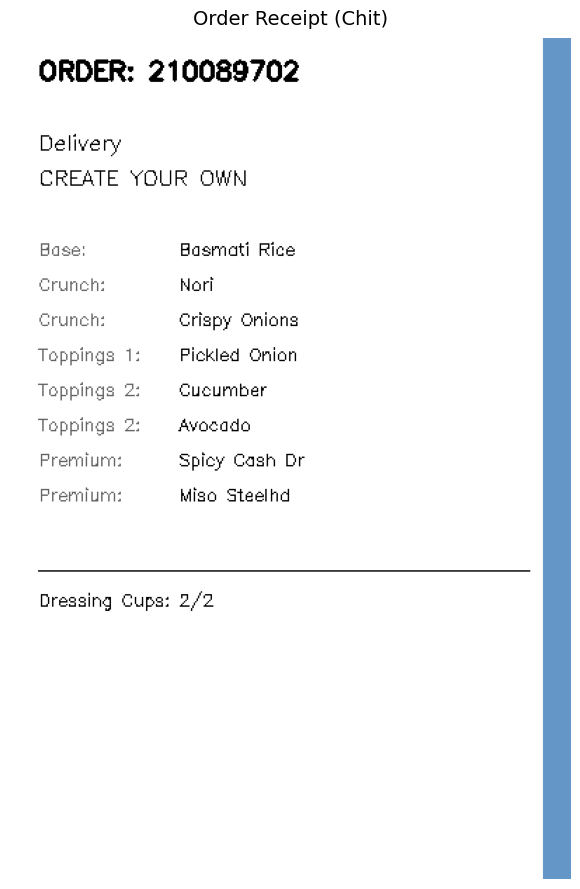

Chit criado com sucesso!


In [23]:
# Create a visual representation of the order receipt (chit)
def create_chit_image():
    """Create an artificial receipt/chit image with order information."""
    # Create white background (receipt-like)
    chit_width = 400
    chit_height = 600
    chit_img = np.ones((chit_height, chit_width, 3), dtype=np.uint8) * 255
    
    # Add blue line on the right (like real receipts)
    cv2.rectangle(chit_img, (chit_width - 20, 0), (chit_width, chit_height), (200, 150, 100), -1)
    
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_small = cv2.FONT_HERSHEY_SIMPLEX
    y_pos = 30
    line_height = 25
    
    # Header
    cv2.putText(chit_img, "ORDER: 210089702", (20, y_pos), font, 0.6, (0, 0, 0), 2)
    y_pos += line_height * 2
    cv2.putText(chit_img, "Delivery", (20, y_pos), font_small, 0.5, (0, 0, 0), 1)
    y_pos += line_height
    cv2.putText(chit_img, "CREATE YOUR OWN", (20, y_pos), font_small, 0.5, (0, 0, 0), 1)
    y_pos += line_height * 2
    
    # Order items
    order_items = [
        ("Base:", "Basmati Rice"),
        ("Crunch:", "Nori"),
        ("Crunch:", "Crispy Onions"),
        ("Toppings 1:", "Pickled Onion"),
        ("Toppings 2:", "Cucumber"),
        ("Toppings 2:", "Avocado"),
        ("Premium:", "Spicy Cash Dr"),
        ("Premium:", "Miso Steelhd"),
    ]
    
    for category, item in order_items:
        cv2.putText(chit_img, category, (20, y_pos), font_small, 0.4, (100, 100, 100), 1)
        cv2.putText(chit_img, item, (120, y_pos), font_small, 0.4, (0, 0, 0), 1)
        y_pos += line_height
    
    # Footer
    y_pos += line_height
    cv2.line(chit_img, (20, y_pos), (chit_width - 30, y_pos), (0, 0, 0), 1)
    y_pos += line_height
    cv2.putText(chit_img, "Dressing Cups: 2/2", (20, y_pos), font_small, 0.4, (0, 0, 0), 1)
    
    return chit_img

# Create and display the chit
chit_img = create_chit_image()
chit_rgb = cv2.cvtColor(chit_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 9))
plt.imshow(chit_rgb)
plt.axis('off')
plt.title("Order Receipt (Chit)", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

print("Chit criado com sucesso!")


In [24]:
# Fixed chit ingredients (from the receipt/note)
CHIT_INGREDIENTS = [
    "Basmati Rice",  # Base
    "Nori",  # Crunch
    "Crispy Onions",  # Crunch
    "Pickled Onion",  # Toppings 1
    "Cucumber",  # Toppings 2
    "Avocado",  # Toppings 2
    "Spicy Cash Dr",  # Premium (Spicy Cashew Dressing)
    "Miso Steelhd",  # Premium (Miso Steelhead)
]

# Map detected objects to chit ingredients (normalize names)
INGREDIENT_MAPPING = {
    "avocado": "Avocado",
    "tomato": "Tomato",
    "cucumber": "Cucumber",
    "cumber": "Cucumber",
}

print("Chit ingredients:")
for ing in CHIT_INGREDIENTS:
    print(f"  - {ing}")


Chit ingredients:
  - Basmati Rice
  - Nori
  - Crispy Onions
  - Pickled Onion
  - Cucumber
  - Avocado
  - Spicy Cash Dr
  - Miso Steelhd


## Load Image


Image loaded: salad4.png
Dimensions: 1280x720


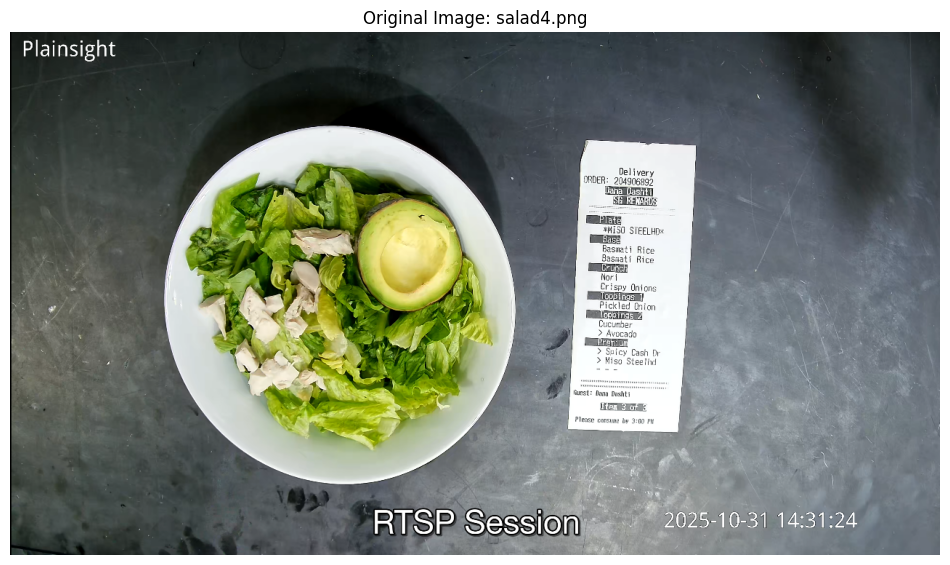

In [25]:
# Load image
img_bgr = cv2.imread(str(image_path))
if img_bgr is None:
    raise ValueError(f"Could not load image: {image_path}")

# Resize if needed (for consistency with video processing)
img_bgr = cv2.resize(img_bgr, (1280, 720))

# Convert BGR to RGB for visualization
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"Image loaded: {image_path.name}")
print(f"Dimensions: {img_bgr.shape[1]}x{img_bgr.shape[0]}")

# Visualize original image
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f"Original Image: {image_path.name}")
plt.show()


## Initialize SAM3 Detector


In [26]:
# Initialize detector (will update prompt for each object)
detector = FilterSAM3Detector({
    "text_prompt": objects_to_detect[0],
    "confidence_threshold": confidence_threshold,
    "device": "cuda",
    "visualize": False,
    "output_label": "detections",
})

detector.setup(detector.config)
print("SAM3 Detector initialized successfully!")


2025-12-22 19:07:54.609 2513381 INFO     [Filter] Raw subject data export is DISABLED (set OPENLINEAGE_EXPORT_RAW_DATA=true to enable)
2025-12-22 19:07:54.612 2513381 INFO     FilterSAM3Detector(config={'text_prompt': 'avocado', 'confidence_threshold': 0.2, 'device': 'cuda', 'visualize': False, 'output_label': 'detections', 'id': 'FilterSAM3Detector-vXuTEo'})
2025-12-22 19:07:54.631 2513381 INFO     ==========================================
2025-12-22 19:07:54.633 2513381 INFO     FilterSAM3Detector setup: {'text_prompt': 'avocado', 'confidence_threshold': 0.2, 'device': 'cuda', 'visualize': False, 'output_label': 'detections', 'id': 'FilterSAM3Detector-vXuTEo'}
2025-12-22 19:07:54.635 2513381 INFO     ==========================================
2025-12-22 19:07:54.636 2513381 INFO     Using device: cuda
2025-12-22 19:07:54.639 2513381 INFO     Loading SAM3 model on device: cuda
2025-12-22 19:07:54.642 2513381 INFO     Found BPE file at: /home/leandrobmarinho/datasets/filter-sam3-detec

SAM3 Detector initialized successfully!


## Process Image for Detection


In [27]:
# Process each object type separately
all_detections = []

print("Processing image for each object type...")
for obj_label in objects_to_detect:
    print(f"\nDetecting: {obj_label}")
    
    # Update detector prompt for this object
    detector.cfg.text_prompt = obj_label
    detector.text_prompt = obj_label
    
    # Create Frame object
    frame = Frame(image=img_bgr, format="BGR")
    frames_dict = {"frames": frame}
    
    # Run detection
    detected = detector.process(frames_dict)
    
    # Extract detections and label them
    if detected:
        for topic, frame in detected.items():
            dets = frame.data.get('meta', {}).get('detections', [])
            for det in dets:
                labeled_det = det.copy()
                labeled_det['label'] = obj_label
                all_detections.append(labeled_det)
            break
    
    print(f"  Found {len([d for d in all_detections if d.get('label') == obj_label])} {obj_label}(s)")

print(f"\nTotal detections before filtering: {len(all_detections)}")

# Filter detections by minimum score
filtered_detections = [det for det in all_detections if det.get('score', 0.0) >= min_score_filter]
all_detections = filtered_detections

print(f"Total detections after filtering (score >= {min_score_filter}): {len(all_detections)}")


Processing image for each object type...

Detecting: avocado


  Found 1 avocado(s)

Detecting: tomato
  Found 0 tomato(s)

Detecting: cucumber
  Found 0 cucumber(s)

Total detections before filtering: 1
Total detections after filtering (score >= 0.3): 1


## Order UI Function

Função para desenhar a interface de monitoramento de pedidos:


In [28]:
def draw_order_ui(img, detected_ingredients_set, frame_time_str, has_bowl=False, has_chit=False):
    """Draw simplified order monitoring UI overlay on the image."""
    h, w = img.shape[:2]
    
    # Create overlay for UI elements
    overlay = img.copy()
    
    font_ui = cv2.FONT_HERSHEY_SIMPLEX
    font_status = cv2.FONT_HERSHEY_SIMPLEX
    
    # 1. Top-left: Status indicator (ONLINE, Connected) with green border
    status_box_w = 200
    status_box_h = 80
    status_x = 10
    status_y = 10
    
    # Draw black background
    cv2.rectangle(overlay, 
                 (status_x, status_y), 
                 (status_x + status_box_w, status_y + status_box_h),
                 (0, 0, 0), -1)
    
    # Draw green border
    cv2.rectangle(overlay,
                 (status_x, status_y),
                 (status_x + status_box_w, status_y + status_box_h),
                 (0, 255, 0), 2)
    
    # Draw status text
    cv2.putText(overlay, "ONLINE", 
               (status_x + 10, status_y + 30),
               font_status, 0.7, (255, 255, 255), 2)
    cv2.putText(overlay, "Connected", 
               (status_x + 10, status_y + 60),
               font_status, 0.5, (200, 200, 200), 1)
    
    # 2. Top-right: Status panel (Dressing Cups, Bowl, Chit) with green border
    panel_padding = 15
    panel_x = w - 220
    panel_y = 10
    panel_w = 210
    panel_h = 100
    
    # Draw black background
    cv2.rectangle(overlay,
                 (panel_x, panel_y),
                 (panel_x + panel_w, panel_y + panel_h),
                 (0, 0, 0), -1)
    
    # Draw green border
    cv2.rectangle(overlay,
                 (panel_x, panel_y),
                 (panel_x + panel_w, panel_y + panel_h),
                 (0, 255, 0), 2)
    
    # Draw panel content
    y_pos = panel_y + 25
    line_spacing = 25
    
    # Dressing Cups (fixed as 0/0 for now)
    cv2.putText(overlay, "Dressing Cups: 0/0",
               (panel_x + panel_padding, y_pos),
               font_ui, 0.5, (255, 255, 255), 1)
    y_pos += line_spacing
    
    # Bowl: YES/NO
    bowl_text = "Bowl: YES" if has_bowl else "Bowl: NO"
    bowl_color = (255, 255, 255) if has_bowl else (0, 255, 255)  # White if YES, Yellow if NO
    cv2.putText(overlay, bowl_text,
               (panel_x + panel_padding, y_pos),
               font_ui, 0.5, bowl_color, 1)
    y_pos += line_spacing
    
    # Chit: YES/NO
    chit_text = "Chit: YES" if has_chit else "Chit: NO"
    chit_color = (255, 255, 255) if has_chit else (0, 255, 255)  # White if YES, Yellow if NO
    cv2.putText(overlay, chit_text,
               (panel_x + panel_padding, y_pos),
               font_ui, 0.5, chit_color, 1)
    
    # 3. Bottom-right: Timestamp
    timestamp_x = w - 200
    timestamp_y = h - 50
    cv2.putText(overlay, frame_time_str,
               (timestamp_x, timestamp_y),
               font_ui, 0.5, (255, 255, 255), 1)
    
    # 4. Bottom: Status bar - COMPLETE if all chit ingredients are detected
    # Check which chit ingredients match detected ingredients
    detected_chit_count = 0
    for chit_ingredient in CHIT_INGREDIENTS:
        chit_lower = chit_ingredient.lower()
        for det_ingredient in detected_ingredients_set:
            det_lower = det_ingredient.lower()
            # Check if detected ingredient matches chit ingredient
            if (chit_lower in det_lower or det_lower in chit_lower or 
                any(word in det_lower for word in chit_lower.split() if len(word) > 3) or
                any(word in chit_lower for word in det_lower.split() if len(word) > 3)):
                detected_chit_count += 1
                break
    
    # Mark as COMPLETE if we have detections matching chit ingredients and bowl/chit are present
    key_ingredients = ["cucumber", "avocado"]
    key_detected = any(key in det.lower() for det in detected_ingredients_set for key in key_ingredients)
    
    all_complete = (key_detected and has_bowl and has_chit and len(detected_ingredients_set) > 0)
    
    bar_h = 40
    if all_complete:
        status_color = (0, 255, 0)  # Green - COMPLETE
        status_text = "COMPLETE"
        cv2.rectangle(overlay,
                     (0, h - bar_h),
                     (w, h),
                     status_color, -1)
        cv2.putText(overlay, status_text,
                   (w // 2 - 60, h - 10),
                   font_status, 0.8, (255, 255, 255), 2)
    
    # Blend overlay with original image (less opacity for cleaner look)
    cv2.addWeighted(overlay, 0.85, img, 0.15, 0, img)
    
    return img

print("Order UI function defined!")


Order UI function defined!


In [29]:
# Get detected ingredients
detected_labels = set(det.get('label', 'unknown') for det in all_detections)
detected_ingredients_set = set()
for label in detected_labels:
    # Normalize label names
    normalized = INGREDIENT_MAPPING.get(label.lower(), label.capitalize())
    detected_ingredients_set.add(normalized)

print(f"Detected ingredients: {detected_ingredients_set}")

# Determine if bowl and chit are present
has_bowl = len(all_detections) > 0  # Simple heuristic: bowl present if detections exist
has_chit = True  # Assume chit is always present

# Get current timestamp
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Create image with UI
img_with_ui = img_bgr.copy()

# Draw order UI overlay
img_with_ui = draw_order_ui(img_with_ui, detected_ingredients_set, current_time, has_bowl, has_chit)

# Color map for bounding boxes (BGR for OpenCV)
label_colors_bgr = {
    "avocado": (0, 255, 0),      # Green
    "tomato": (0, 0, 255),      # Red
    "cucumber": (255, 255, 0),   # Cyan
    "cup": (255, 0, 0),         # Blue
    "dressing_cup": (255, 0, 0), # Blue
}
default_color_bgr = (0, 255, 255)  # Yellow for unknown

# Draw bounding boxes
for det in all_detections:
    label = det.get('label', 'unknown')
    box = det.get('box', [])
    score = det.get('score', 0.0)
    
    if len(box) == 4:
        x1, y1, x2, y2 = box
        color = label_colors_bgr.get(label.lower(), default_color_bgr)
        
        # Draw rectangle
        cv2.rectangle(img_with_ui, (x1, y1), (x2, y2), color, 3)
        
        # Add label
        label_text = f"{label}"
        
        (text_width, text_height), baseline = cv2.getTextSize(
            label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
        )
        
        cv2.rectangle(img_with_ui, 
                     (x1, y1 - text_height - 10),
                     (x1 + text_width + 6, y1),
                     (255, 255, 255), -1)
        
        cv2.putText(img_with_ui, label_text, (x1 + 3, y1 - 5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

print("UI and detections applied!")


Detected ingredients: {'Avocado'}
UI and detections applied!


## Visualize Result


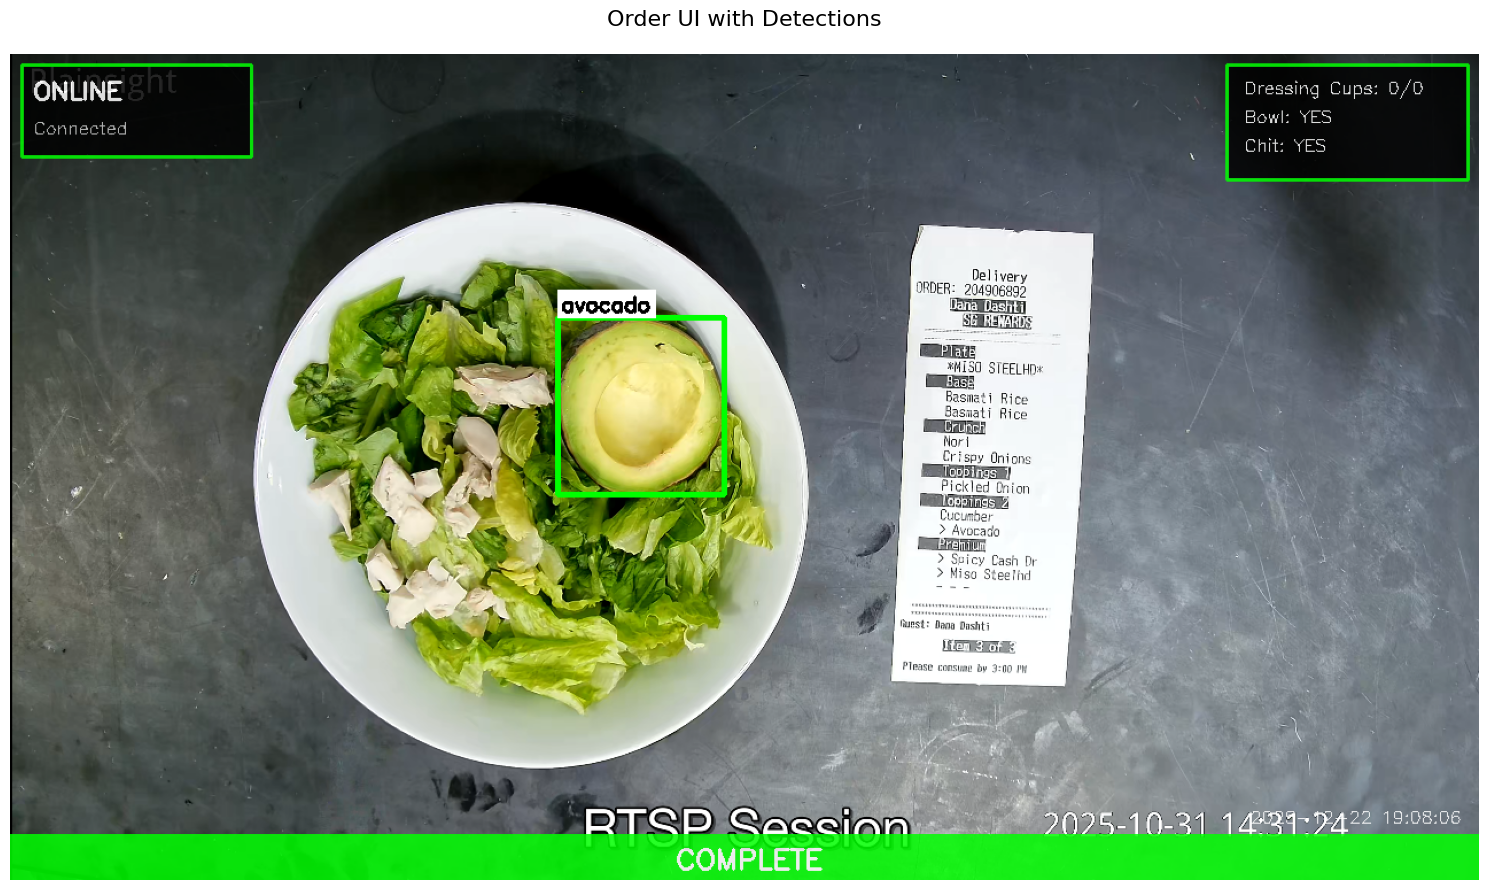


Detections summary:
  - Total detections: 1
  - Detected ingredients: {'Avocado'}
  - Bowl: YES
  - Chit: YES


In [30]:
# Convert BGR to RGB for visualization
img_with_ui_rgb = cv2.cvtColor(img_with_ui, cv2.COLOR_BGR2RGB)

# Visualize result
plt.figure(figsize=(16, 9))
plt.imshow(img_with_ui_rgb)
plt.axis('off')
plt.title("Order UI with Detections", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print(f"\nDetections summary:")
print(f"  - Total detections: {len(all_detections)}")
print(f"  - Detected ingredients: {detected_ingredients_set}")
print(f"  - Bowl: {'YES' if has_bowl else 'NO'}")
print(f"  - Chit: {'YES' if has_chit else 'NO'}")
